In [51]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.stats import pearsonr
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from collections import defaultdict
import community as community_louvain
from pathlib import Path  



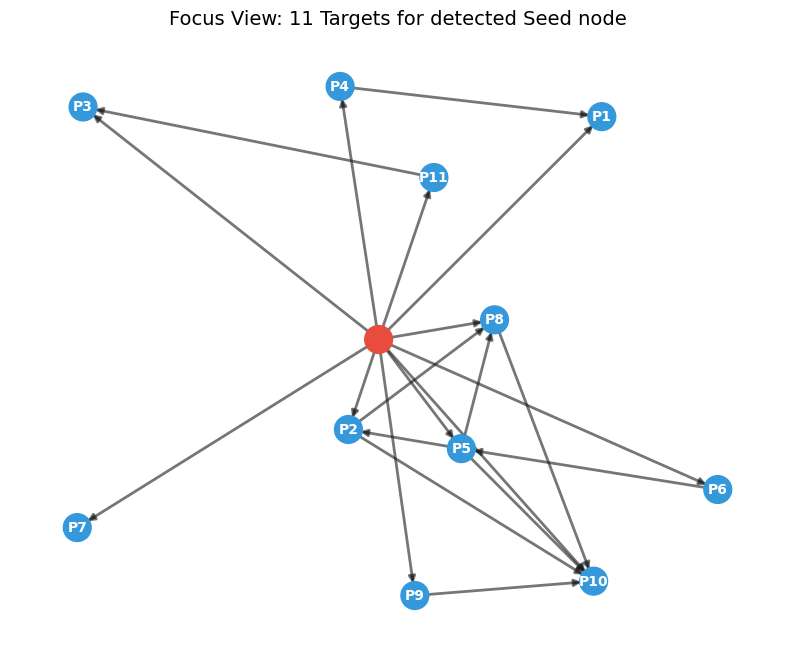

Verified: Found 11 connections for seed 10.1145/3543873.3587570


In [52]:
# 1. Load data
DIRECTORY = Path.cwd().parent / "csv"
nodes_df = pd.read_csv(DIRECTORY / 'knowledge_graph_nodes.csv')
edges_df = pd.read_csv(DIRECTORY / 'knowledge_graph_edges.csv')

# 2. Automatically find the Seed DOI from the nodes file
# This makes the code work for any file you upload
seed_nodes = nodes_df[nodes_df['Type'] == 'Seed']['NodeID'].tolist()

if not seed_nodes:
    print("No node with Type='Seed' found.")
else:
    # Focus on the first seed found
    dynamic_seed = seed_nodes[0]
    
    # 3. Build the Graph
    G = nx.from_pandas_edgelist(edges_df, source='Source', target='Target', create_using=nx.DiGraph())

    # 4. Identify the neighbors (targets) for the dynamic seed
    if dynamic_seed in G:
        neighbors = list(G.neighbors(dynamic_seed))
        nodes_to_show = [dynamic_seed] + neighbors
        H = G.subgraph(nodes_to_show)

        # 5. Calculate Layout with high repulsion (k) to avoid overlap
        # k=1.0 provides a very wide spread
        pos = nx.spring_layout(H, k=1.0, seed=42)

        # 6. Add Jitter to ensure 100% visibility of overlapping dots
        for node in pos:
            pos[node] = pos[node] + np.random.uniform(-0.04, 0.04, size=2)

        plt.figure(figsize=(10, 8))

        # 7. Draw the focused network
        nx.draw_networkx_edges(H, pos, width=2, edge_color="#1a1b1b", alpha=0.6)
        
        # Color: Seed is Red, others are Blue/Orange
        node_colors = ['#e74c3c' if n == dynamic_seed else '#3498db' for n in H.nodes()]
        nx.draw_networkx_nodes(H, pos, node_size=400, node_color=node_colors)

        # 8. Dynamic Labels: Show 'SEED' and references of seed paper as'P1, P2, P3...'
        label_map = {n: "SEED" if n == dynamic_seed else f"P{i}" 
                     for i, n in enumerate(neighbors, 1)}
        nx.draw_networkx_labels(H, pos, labels=label_map, font_size=10, font_color='white', font_weight='bold')

        plt.title(f"Focus View: {len(neighbors)} Targets for detected Seed node", fontsize=14)
        plt.axis('off')
        plt.show()
        
        print(f"Verified: Found {len(neighbors)} connections for seed {dynamic_seed}")
    else:
        print(f"Seed DOI {dynamic_seed} has no connections in the edges file.")

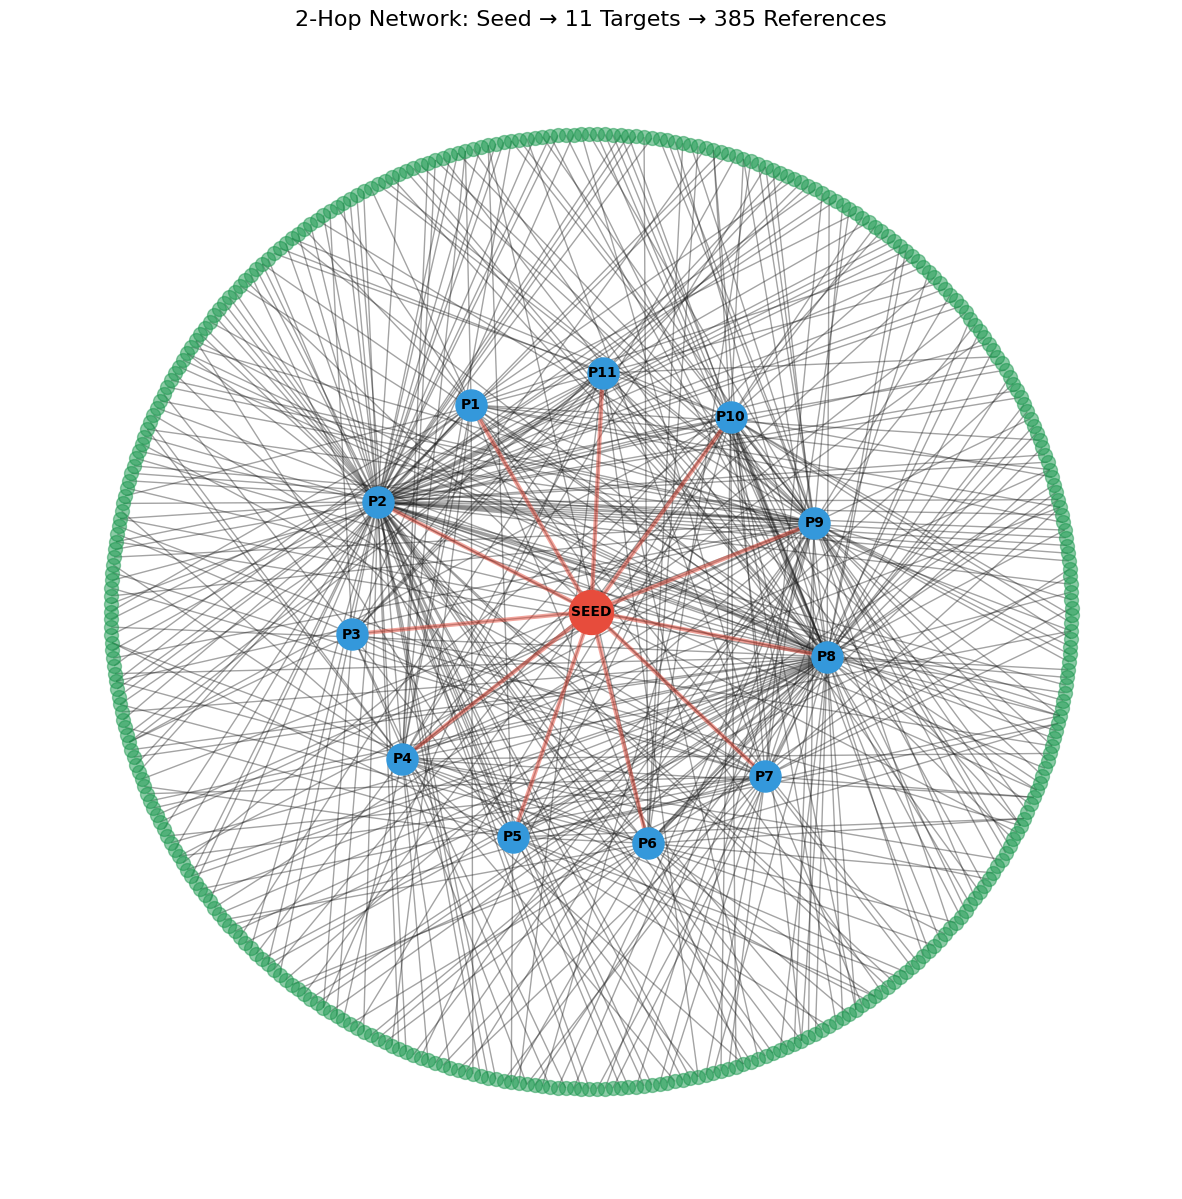

Count Check: Seed (1) + Targets (11) + References of Targets (385)


In [85]:
# 2. Build the Graph
G = nx.from_pandas_edgelist(edges_df, source='Source', target='Target', create_using=nx.Graph())
node_attr = nodes_df.set_index('NodeID').to_dict('index')
nx.set_node_attributes(G, node_attr)

# 3. Detect Layers Dynamically
# Find the Seed automatically
seeds = [n for n, attr in G.nodes(data=True) if attr.get('Type') == 'Seed']
seed = seeds[0]

# Level 1: Neighbors of the Seed (The 10 Targets)
level1 = list(G.neighbors(seed))

# Level 2: Neighbors of the Targets (The References of Targets)
level2 = set()
for n in level1:
    for neighbor in G.neighbors(n):
        if neighbor != seed and neighbor not in level1:
            level2.add(neighbor)
level2 = list(level2)

# 4. Create the Shell Layout
# This forces nodes into circles: [Center, Middle Ring, Outer Ring]
shells = [[seed], level1, level2]
pos = nx.shell_layout(G.subgraph([seed] + level1 + level2), shells)

# 5. Visualization
plt.figure(figsize=(15, 15))

# Draw everything
nx.draw_networkx_nodes(G, pos, nodelist=[seed], node_color='#e74c3c', node_size=1000, label='Seed')
nx.draw_networkx_nodes(G, pos, nodelist=level1, node_color='#3498db', node_size=500, label='Targets')
nx.draw_networkx_nodes(G, pos, nodelist=level2, node_color="#1b984f", node_size=100, alpha=0.5, label='Ref of Ref')

# Draw connections
nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color="#1b1b1b")
# Highlight Seed -> Target connections in Red
nx.draw_networkx_edges(G, pos, edgelist=[(seed, n) for n in level1], width=3, edge_color="#e74c3c", alpha=0.5)

# Label the 10 Targets as P1, P2... P10 so you can count them easily
labels = {n: f"P{i+1}" for i, n in enumerate(level1)}
labels[seed] = "SEED"
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold')

plt.title(f"2-Hop Network: Seed → {len(level1)} Targets → {len(level2)} References", fontsize=16)
plt.axis('off')
plt.show()

print(f"Count Check: Seed (1) + Targets ({len(level1)}) + References of Targets ({len(level2)})")

Katz Prestige (or Centrality) Calculation

In [58]:
# Katz Centrality Calculation
edges_df_cleaned = edges_df.dropna(subset=["Source", "Target"])

#Convert edge list to directed graph
G_original = nx.from_pandas_edgelist(edges_df_cleaned, source='Source', target='Target', create_using=nx.DiGraph())

alpha = 0.005
katz_centrality = nx.katz_centrality_numpy(G_original, alpha=alpha)

katz_df = pd.DataFrame(katz_centrality.items(), columns=["DOI", "Katz_Prestige"])

katz_df = katz_df.dropna(subset=["DOI"])

katz_df = katz_df.sort_values(by="Katz_Prestige", ascending=False).reset_index(drop=True)

katz_df.head(15)

,DOI,Katz_Prestige
0,10.1145/2623330.2623732,0.051152
1,10.1145/2939672.2939754,0.050903
2,10.1109/TPAMI.2013.50,0.050656
3,10.1201/b17320-16,0.050653
4,10.1016/j.knosys.2018.03.022,0.050648
5,10.18653/v1/N19-1423,0.050648
6,10.1145/2740908.2742839,0.050648
7,10.18653/v1/N18-1202,0.050648
8,10.18653/v1/P18-1031,0.050648
9,10.17863/CAM.48429,0.050648


Pearson correlation coefficient can be used to measure the linear relationship between Katz prestige scores. How katz prestige ranking change when a network slightly altered. It is revealing the robustness of the network.

<Figure size 800x500 with 0 Axes>

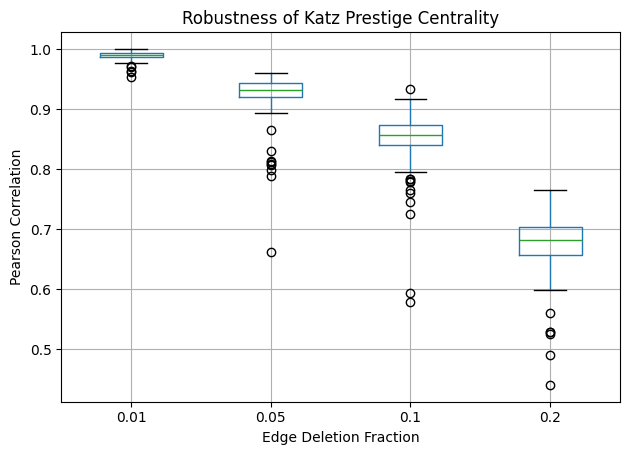

In [55]:
#Pearson Correlation in Katz Prestige
delete_fractions = [0.01, 0.05, 0.10, 0.20]
num_repeats = 100
# G_original = nx.from_pandas_edgelist(edges_df, source='Source', target='Target', create_using=nx.DiGraph())
katz_orig_rank = pd.Series(katz_centrality).rank(method="min")

results = []
for frac in delete_fractions:
    for run in range(num_repeats):
        G_temp = G_original.copy()
        num_edges = int(frac * G_temp.number_of_edges())
        removed_edges = random.sample(list(G_temp.edges()), num_edges)
        G_temp.remove_edges_from(removed_edges)

        try:
            katz_temp = nx.katz_centrality_numpy(G_temp, alpha=alpha)
            katz_temp_rank = pd.Series(katz_temp).reindex(katz_orig_rank.index).rank(method="min")
            corr, _ = pearsonr(katz_orig_rank, katz_temp_rank)
        except:
            corr = np.nan  

        results.append({
            "Fraction_Removed": frac,
            "Run": run,
            "Pearson_Correlation": corr
        })


results_df = pd.DataFrame(results)
results_df.head(15)


plt.figure(figsize=(8, 5))
results_df.boxplot(column="Pearson_Correlation", by="Fraction_Removed")
plt.title("Robustness of Katz Prestige Centrality")
plt.suptitle("")
plt.xlabel("Edge Deletion Fraction")
plt.ylabel("Pearson Correlation")
plt.grid(True)
plt.tight_layout()
# plt.savefig("katz_robustness_plot.png")
plt.show()

Lovain Comunity Detection 

Modularity Score: 0.7307
Seed Paper '10.1145/3543873.3587570' is in Community: 0


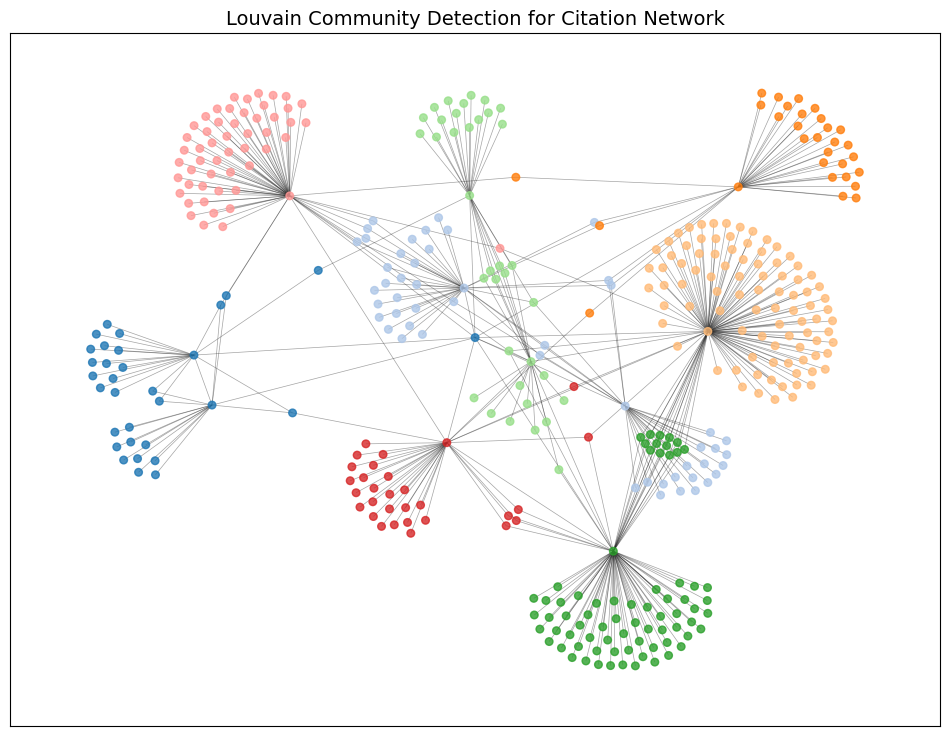

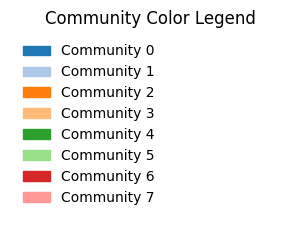

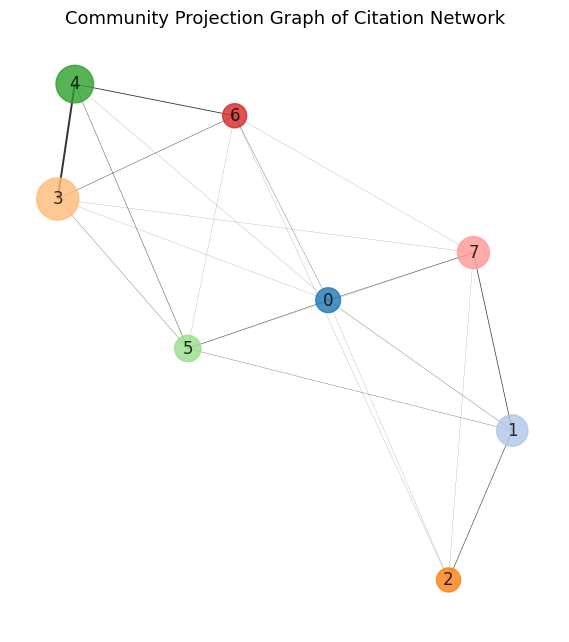

In [ ]:
seed_paper = "10.1145/3543873.3587570"
G = nx.from_pandas_edgelist(edges_df
                            , "Source", "Target", edge_attr=True, create_using=nx.Graph())

partition = community_louvain.best_partition(G, resolution=1.0)


modularity = community_louvain.modularity(partition, G)
print(f"Modularity Score: {modularity:.4f}")

core_comm = partition.get(seed_paper, "Not Found")
print(f"Seed Paper '{seed_paper}' is in Community: {core_comm}")

communities = defaultdict(list)
for node, cid in partition.items():
    communities[cid].append(node)

community_df = pd.DataFrame([(cid, act) for cid, acts in communities.items() for act in acts],
                            columns=["Community", "DOI"])
# community_df.head(50)
# Community ids and dois save to CSV
community_df.to_csv("community_ids_with_dois.csv", index=False)

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G,  center=(0, 0), seed=21)
base_cmap = plt.get_cmap("tab20")
colors = lambda i: base_cmap(i % base_cmap.N)
node_colors = [colors(partition[node]) for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=30, alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color="#1b1b1b", width=0.5, alpha=0.4)
plt.title("Louvain Community Detection for Citation Network", fontsize=14)
# plt.savefig("louvain_community_network.png", dpi=300, bbox_inches='tight')
plt.show()

# Community Color Legend
fig, ax = plt.subplots(figsize=(4, len(communities) * 0.3))  
fig.subplots_adjust(left=0.2)
patches = [mpatches.Patch(color=colors(i), label=f"Community {i}") for i in sorted(communities.keys())]
legend = ax.legend(handles=patches, loc='center left', fontsize=10, frameon=False)
ax.axis('off')  
plt.title("Community Color Legend", fontsize=12)
# plt.savefig("community_legend.png", dpi=300, bbox_inches='tight')
plt.show()

# Community Projection Graph 
G_proj = nx.Graph()
for cid, nodes in communities.items():
    G_proj.add_node(cid, size=len(nodes))

for u, v, data in G.edges(data=True):
    cu = partition[u]
    cv = partition[v]
    if cu != cv:
        if G_proj.has_edge(cu, cv):
            G_proj[cu][cv]['weight'] += 1
        else:
            G_proj.add_edge(cu, cv, weight=1)


plt.figure(figsize=(5.5, 6))
proj_pos = nx.spring_layout(G_proj, seed=42, k=1.5)
proj_colors = [colors(n) for n in G_proj.nodes()]
proj_sizes = [G_proj.nodes[n]['size'] * 10 for n in G_proj.nodes()]
edge_widths = [G_proj[u][v]['weight'] / 10 for u, v in G_proj.edges()]
nx.draw(G_proj, proj_pos, with_labels=True, node_color=proj_colors,
        node_size=proj_sizes, width=edge_widths, edge_color='black', alpha=0.8)
plt.title("Community Projection Graph of Citation Network", fontsize=13)
# plt.savefig("community_projection_graph.png", dpi=300, bbox_inches='tight')
plt.show()
